## Activations Functions
## General case

<!-- Open in Colab -->

<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/snn_activations.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



Activation functions are what make a neural network more than a fancy linear regression. Recall that a shallow network first combines the input into several linear pre-activations, then passes each one through an activation function $a[\bullet]$ before recombining the results into the output. Without that nonlinear step, composing linear functions of linear functions is still just a linear function -- no matter how many hidden units or layers you stack on, the whole network could be collapsed back down to a single linear map (see the Linear Activation Functions section below). It's specifically the *nonlinearity* introduced by $a[\bullet]$ that lets the network bend, kink, or curve its output enough to approximate genuinely complicated functions.

There isn't one "correct" choice of activation function -- different functions trade off smoothness, computational cost, and (as we'll see once we get to fitting models) how well gradient information flows through them during training. The rest of this page walks through several common choices -- ReLU, the sigmoid, the heaviside step function, and a deliberately-broken linear activation -- alongside a gallery of other activations used in modern practice.

\begin{eqnarray}\label{eq:snn_harswish}
 \mbox{HardSwish}[z] = \begin{cases} 0 & \quad z <-3 \\ z(z+3)/6 & \quad -3\leq z\leq 3 \\ z &\quad z>3 \end{cases}.
 \end{eqnarray}

\begin{eqnarray}
  \mbox{ReLU}[\alpha \cdot z] = \alpha \cdot \mbox{ReLU}[z].
 \end{eqnarray}

\begin{eqnarray}
 \mbox{heaviside}[z] = \begin{cases} 0 & \quad z <0 \\ 1 & \quad z\geq 0\end{cases} \hspace{2cm} \mbox{rect}[z] = \begin{cases} 0 & \quad z < 0 \\ 1 & \quad 0 \leq z\leq 1 \\ 0 & \quad z > 1\end{cases}.
 \end{eqnarray}


<img src="assets/Chap03/ShallowActivations.svg" style="filter: invert(1);" width="100%">

Activation functions. a) Logistic sigmoid and tanh functions. b)
Leaky ReLU and parametric ReLU with parameter 0.25. c) SoftPlus, Gaussian
error linear unit, and sigmoid linear unit. d) Exponential linear unit with parameters
0.5 and 1.0, e) Scaled exponential linear unit. f) Swish with parameters 0.4,
1.0, and 1.4.


<img src="assets/Chap03/ShallowChangeSlope.svg" style="filter: invert(1);" width="100%">


Processing in network with one input, three hidden units, and one
output for problem 3.4. a–c) The input to each hidden unit is a linear function of
the inputs. The first two are the same as in figure 3.3, but the last one differs.


In [1]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

plt.style.use('dark_background')

In [2]:
# Plot the shallow neural network.  We'll assume input in is range [0,1] and output [-1,1]
# If the plot_all flag is set to true, then we'll plot all the intermediate stages as in Figure 3.3
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Plot intermediate plots if flag set
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, $x$');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, $x$'); ax.set_ylabel('Output, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

In [3]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Pass these through the ReLU function to compute the activations as in
  # figure 3.3 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [4]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

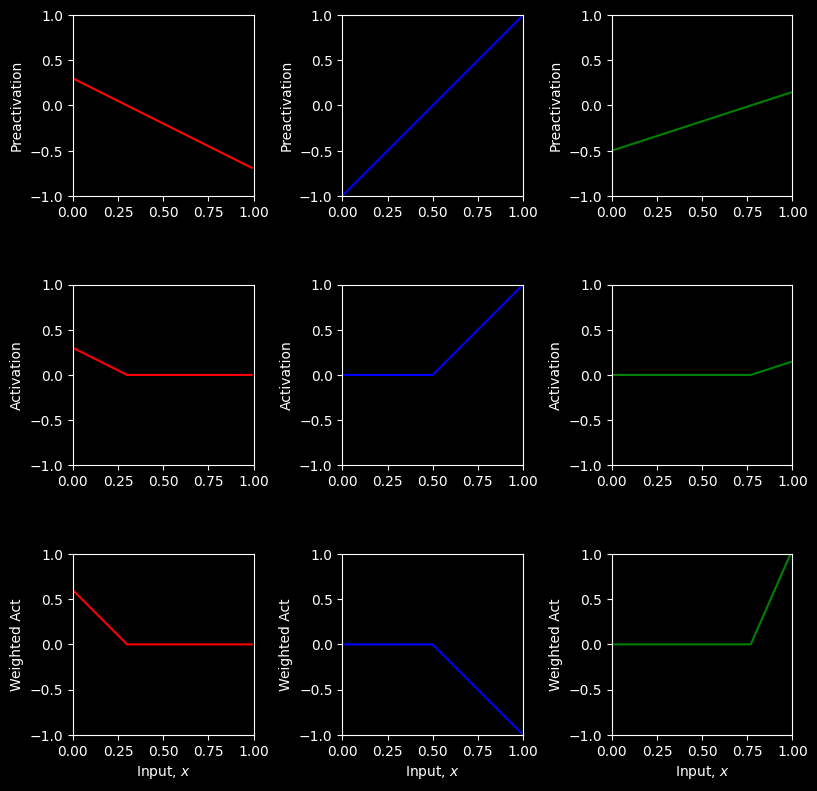

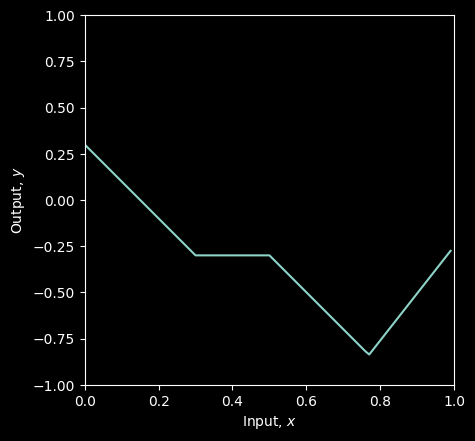

In [5]:
# Now lets define some parameters and run the neural network
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

## Sigmoid activation function

The ReLU isn't the only kind of activation function. For a long time, people used sigmoid functions. A logistic sigmoid function is defined by the equation

$$ f[z] = \frac{1}{1 + \text{exp}[-10z]} $$

(Note that the factor of 10 is not standard -- but it allow us to plot on the same axes as the ReLU examples)

In [6]:
# Define the sigmoid function
def sigmoid(preactivation):
  
  activation = 1/(1 + np.exp(-10*preactivation))

  return activation
     

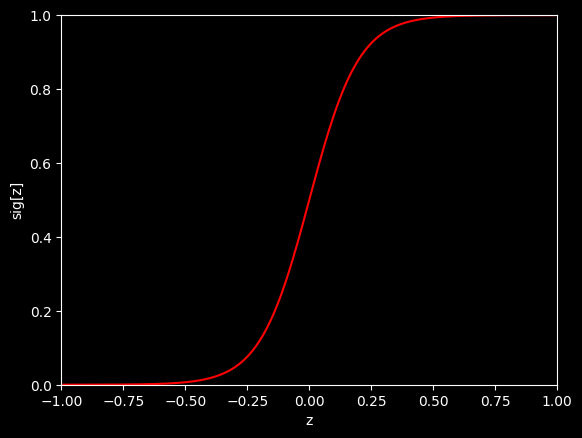

In [7]:
# Make an array of inputs
z = np.arange(-1,1,0.01)
sig_z = sigmoid(z)

# Plot the sigmoid function
fig, ax = plt.subplots()
ax.plot(z,sig_z,'r-')
ax.set_xlim([-1,1]);ax.set_ylim([0,1])
ax.set_xlabel('z'); ax.set_ylabel('sig[z]')
plt.show()

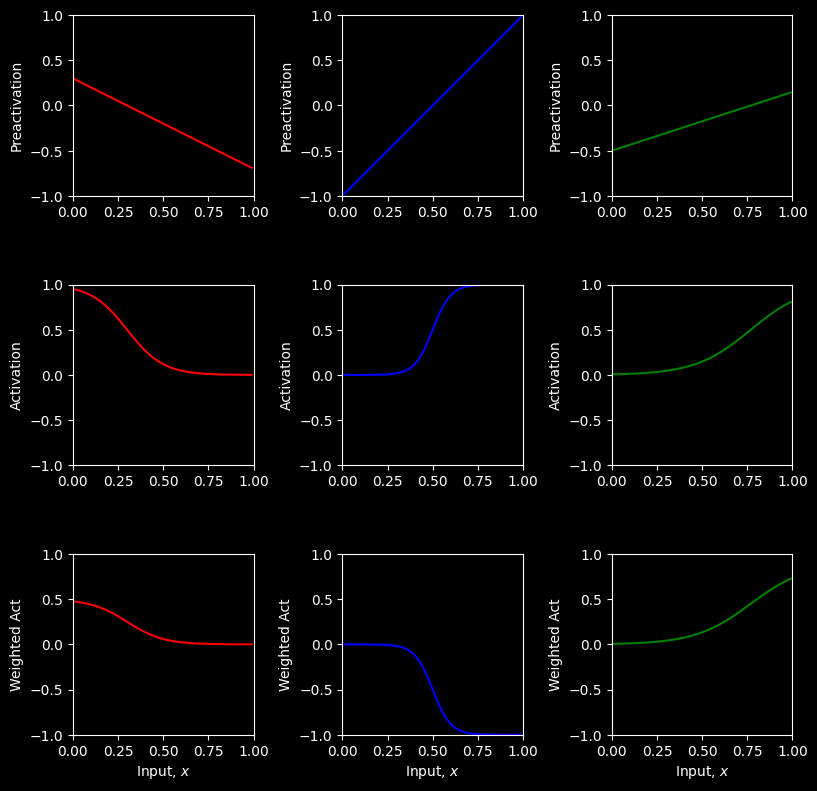

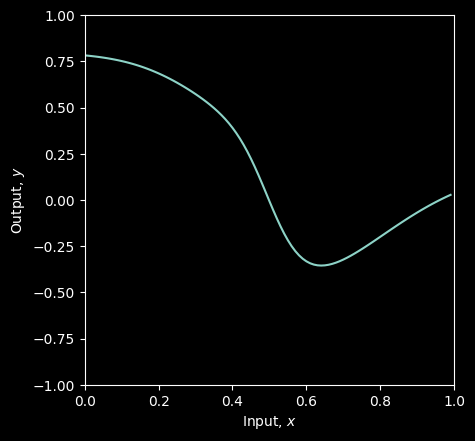

In [8]:
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, sigmoid, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

You probably notice that this gives nice smooth curves. So why don't we use this? Aha... it's not obvious right now, but we will get to it when we learn to fit models.

## Heaviside function 

Heaviside function is defined as 

$$
H(x)=
\begin{cases}
0, & z < 0, \\
1, & z \geq 0.
\end{cases}
$$

In [9]:
# Define the heaviside function
def heaviside(preactivation):
  # TODO write code to implement the heaviside function and compute the activation at the
  # hidden unit from the preactivation.  Depending on your implementation you may need to
  # convert a Boolean array to an array of ones and zeros.  To do this, use .astype(int)
  activation = (preactivation >= 0).astype(int)
  return activation

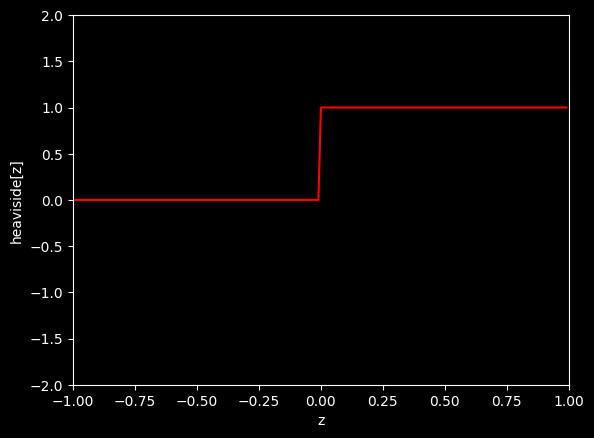

In [10]:
# Make an array of inputs
z = np.arange(-1,1,0.01)
heav_z = heaviside(z)

# Plot the heaviside function
fig, ax = plt.subplots()
ax.plot(z,heav_z,'r-')
ax.set_xlim([-1,1]);ax.set_ylim([-2,2])
ax.set_xlabel('z'); ax.set_ylabel('heaviside[z]')
plt.show()

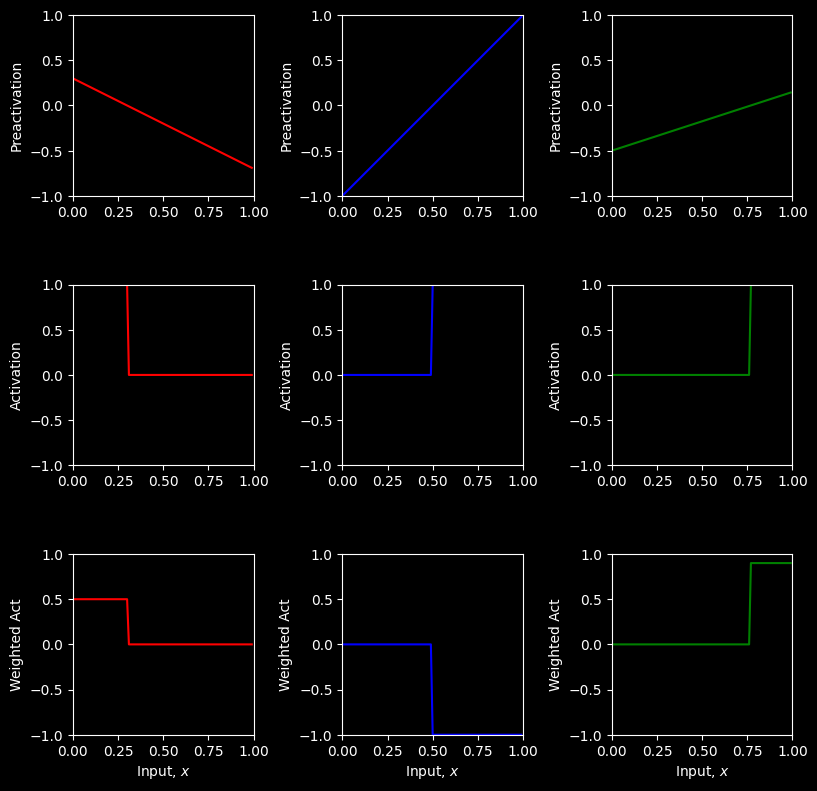

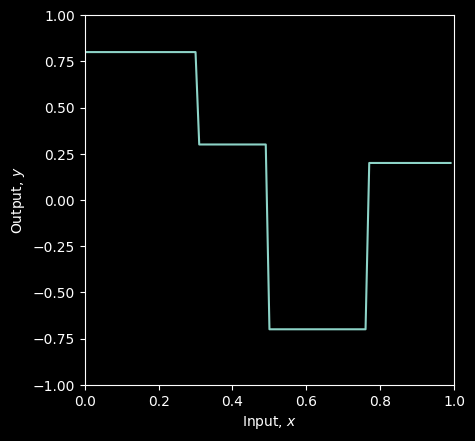

In [11]:
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, heaviside, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

This can approximate any function, but the output is discontinuous, and there are also reasons not to use it that we will discover when we learn more about model fitting.

## Linear Activation functions 

Neural networks don't work if the activation function is linear. For example, consider what would happen if the activation function was:

$$ lin[z] = a + bz $$

In [12]:
# Define the linear activation function
def lin(preactivation):
  a =0
  b =1
  # Compute linear function
  activation = a+b * preactivation
  # Return
  return activation

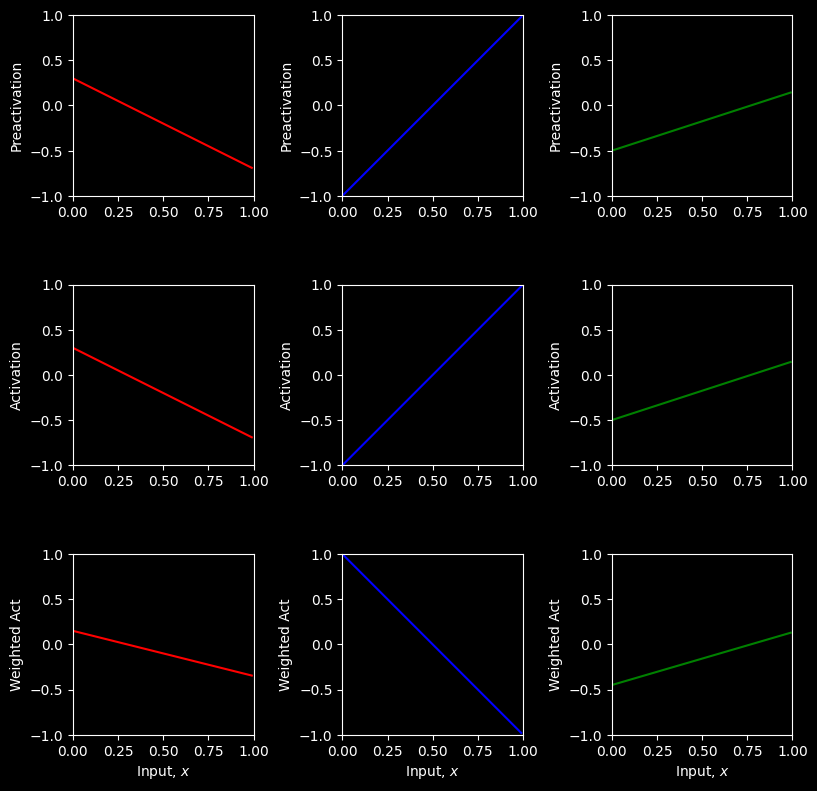

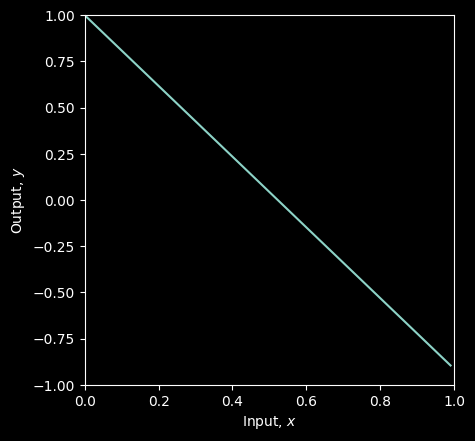

In [13]:
# TODO
# 1. The linear activation function above just returns the input: (0+1*z) = z
# Before running the code Make a prediction about what the ten panels of the drawing will look like
# Now run the code below to see if you were right. What family of functions can this represent?

# 2. What happens if you change the parameters (a,b) to different values?
# Try a=0.5, b=-0.4 Don't forget to run the cell again to update the function

theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, lin, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

## Derivatives of Activation Functions

Everything above focused on what each activation function *outputs*. But when we get to fitting models, what will actually matter is each function's *derivative* -- gradient-based learning adjusts every parameter $\theta_{\bullet}$ by asking how the loss changes as $\theta_{\bullet}$ changes, and that question runs straight through $a'[\bullet]$ via the chain rule. A hidden unit with a well-behaved derivative gives the optimizer a clear signal about which direction to move; a hidden unit whose derivative vanishes gives it nothing to work with, no matter how good the function's output looks.

$$
\begin{aligned}
\text{ReLU}'[z] &= \begin{cases} 0, & z < 0, \\ 1, & z > 0 \end{cases}
&&\text{(undefined exactly at } z=0\text{; we take it to be 0 below)} \\[6pt]
f'[z] &= 10\, f[z]\bigl(1-f[z]\bigr)
&&\text{for the (scaled) sigmoid } f[z] = \dfrac{1}{1+e^{-10z}} \\[6pt]
H'[z] &= 0 \quad \text{for all } z \neq 0
&&\text{(a Dirac delta at } z=0 \text{ in the formal sense)} \\[6pt]
\text{lin}'[z] &= b
&&\text{for } \text{lin}[z] = a + bz
\end{aligned}
$$

In [ ]:
# Derivative of ReLU: 0 for z<0, 1 for z>0 (undefined exactly at z=0; we set it to 0)
def ReLU_derivative(preactivation):
  derivative = (preactivation > 0).astype(float)
  return derivative

# Derivative of the (scaled) sigmoid: f'(z) = 10 * f(z) * (1 - f(z))
def sigmoid_derivative(preactivation):
  f = sigmoid(preactivation)
  derivative = 10 * f * (1 - f)
  return derivative

# Derivative of the heaviside step: 0 everywhere except at z=0, where it is
# formally undefined (a Dirac delta in the limit). We plot it as 0 everywhere,
# since that is exactly what a gradient-based optimizer would see.
def heaviside_derivative(preactivation):
  derivative = np.zeros_like(preactivation)
  return derivative

# Derivative of the linear activation a + bz is just the constant b
def lin_derivative(preactivation, b=1.0):
  derivative = np.full_like(preactivation, b)
  return derivative

In [ ]:
# Compare each activation function (top row) with its derivative (bottom row)
z = np.arange(-1, 1, 0.01)

fig, axs = plt.subplots(2, 4, figsize=(14, 6), sharex=True)

axs[0,0].plot(z, ReLU(z), 'r-');      axs[0,0].set_title('ReLU')
axs[0,1].plot(z, sigmoid(z), 'r-');   axs[0,1].set_title('Sigmoid')
axs[0,2].plot(z, heaviside(z), 'r-'); axs[0,2].set_title('Heaviside')
axs[0,3].plot(z, lin(z), 'r-');       axs[0,3].set_title('Linear')
axs[0,0].set_ylabel('$a[z]$')

axs[1,0].plot(z, ReLU_derivative(z), 'c-')
axs[1,1].plot(z, sigmoid_derivative(z), 'c-')
axs[1,2].plot(z, heaviside_derivative(z), 'c-')
axs[1,3].plot(z, lin_derivative(z), 'c-')
axs[1,0].set_ylabel("$a'[z]$")

for ax in axs.flat:
  ax.set_xlabel('$z$')
  ax.set_xlim([-1, 1])

fig.tight_layout()
plt.show()

Notice the pattern in the bottom row:

- **ReLU's** derivative is a clean step -- exactly 0 on one side of the joint and exactly 1 on the other. This is cheap to compute, but a unit that gets pushed permanently into the $z<0$ region receives a derivative of 0 forever and stops learning entirely. This is the well-known "dying ReLU" problem.
- **Sigmoid's** derivative is smooth everywhere, but it shrinks to 0 as $|z|$ grows large -- the function *saturates*. This saturation is exactly the reason foreshadowed earlier for why we don't just use the nice, smooth sigmoid: stack a few saturating layers together and the gradient reaching the earliest layers can vanish almost completely.
- **Heaviside's** derivative is 0 almost everywhere. Even though the heaviside function can represent sharp, discontinuous decision boundaries, a gradient-based optimizer looking at $H'[z]$ gets no information whatsoever about which direction to adjust $\theta$ -- this, not just the discontinuous output, is the real reason it's never used as a hidden-unit activation in practice.
- **Linear's** derivative is a constant, independent of $z$. Combined with the fact that composing linear functions is still linear, this is exactly why a network built entirely of linear activations can never do more than linear regression, no matter how many hidden units or layers you add.

The activations in the gallery figure above (tanh, Leaky ReLU, GELU, Swish, ELU, ...) were all designed, in one way or another, to dodge one of these two failure modes -- staying non-zero almost everywhere (unlike heaviside) while avoiding the sigmoid's saturation and the plain ReLU's "dead zone."